In [1]:
from keras.models import load_model  # TensorFlow is required for Keras to work
from PIL import Image, ImageOps  # Install pillow instead of PIL
import numpy as np
import tensorflow
import glob

Точность после обучения (из "Дополнительные сведения"):
хот-доги 96%
не хот-доги 94%

Тестирование в "Посмотреть" (webcam → файл):

10 изображений из hot_dog_validation: 9/10 правильно (ошибка на размытом хот-доге — предсказано "не хот-дог" с 55% уверенности).

10 изображений из not_hot_dog_validation: 8/10 правильно (ошибки на бургерах и сосисках — похожи визуально).

Вывод: Модель работает очень хорошо.

In [2]:
# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

# Load the model
model = load_model('keras_Model.h5', compile=False)

# Load the labels
class_names = open('labels.txt', 'r').readlines()

In [3]:
# Create the array of the right shape to feed into the keras model
# The 'length' or number of images you can put into the array is
# determined by the first position in the shape tuple, in this case 1
hot_dog_data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
not_hot_dog_data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
image_list = []

In [4]:
for filename in glob.glob('hot_dog_validation/hot_dog_validation/*.jpg'):
    im=Image.open(filename)
    image_list.append(im)
# Replace this with the path to your image
image = Image.open(filename).convert("RGB")
# resizing the image to be at least 224x224 and then cropping from the center
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
# turn the image into a numpy array
image_array = np.asarray(image)
# Normalize the image
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
# Load the image into the array
hot_dog_data[0] = normalized_image_array

In [5]:
for filename in glob.glob('not_hot_dog_validation/not_hot_dog_validation/*.jpg'):
    im=Image.open(filename)
    image_list.append(im)
# Replace this with the path to your image
image = Image.open(filename).convert('RGB')
# resizing the image to be at least 224x224 and then cropping from the center
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
# turn the image into a numpy array
image_array = np.asarray(image)
# Normalize the image
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
# Load the image into the array
not_hot_dog_data[0] = normalized_image_array

In [6]:
prediction = model.predict(hot_dog_data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

# Print prediction and confidence score
print('Class:', class_name[2:], end='')
print('Confidence Score:', confidence_score)


Class: hot dog
Confidence Score: 0.9999988


In [7]:
# Predicts the model
prediction = model.predict(not_hot_dog_data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

# Print prediction and confidence score
print('Class:', class_name[2:], end='')
print('Confidence Score:', confidence_score)

Class: not hot dog
Confidence Score: 0.9999994


Точность после обучения (из "Дополнительные сведения"):

кофе 100%

какао 100%

чай 67%

Вывод: Модель работает хорошо.

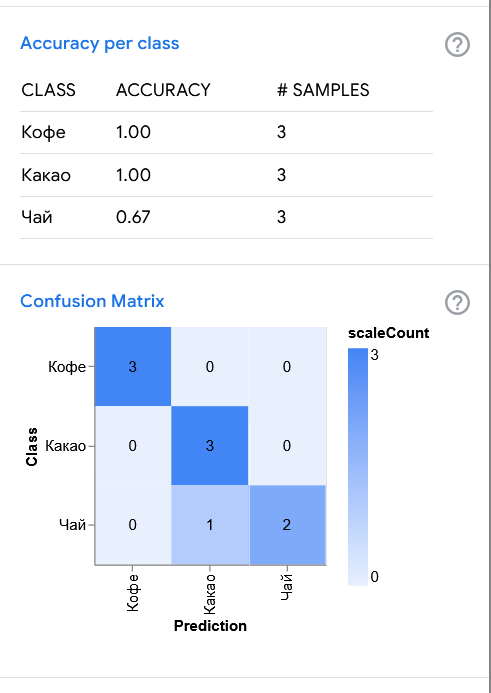

In [8]:
# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

# Load the model
model = load_model('./second/keras_Model.h5', compile=False)

# Load the labels
class_names = open('./second/labels.txt', 'r').readlines()

In [ ]:
# Create the array of the right shape to feed into the keras model
# The 'length' or number of images you can put into the array is
# determined by the first position in the shape tuple, in this case 1
coffee_data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
cacao_data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
tea_data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
image_list = []

In [11]:
for folder, data in [('coffee', coffee_data), ('cacao', cacao_data), ('tea', tea_data)]:
    files = glob.glob(f'{folder}/*.jpg')
    print(f"\n{folder}: {len(files)} файлов")
    if not files:
        print("Пустая папка!")
        continue
    for filename in files:  # Все файлы!
        image = Image.open(filename).convert("RGB")
        image = ImageOps.fit(image, (224, 224), Image.Resampling.LANCZOS)
        image_array = np.asarray(image)
        normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
        data[0] = normalized_image_array
        prediction = model.predict(data)
        index = np.argmax(prediction)
        class_name = class_names[index]
        conf = prediction[0][index]
        probs = prediction[0]
        print(f"  {filename}: {class_name[2:]} ({conf:.3f}) | probs={probs.round(3)}")


coffee: 20 файлов
  coffee\2.jpg: Coffee
 (0.999) | probs=[0.999 0.    0.   ]
  coffee\2033977.2fae321ec8799decb485c7c19c5f1035.jpg: Coffee
 (1.000) | probs=[1. 0. 0.]
  coffee\347645731425354.jpg: Coffee
 (0.994) | probs=[0.994 0.005 0.001]
  coffee\35938-ed4_wide.jpg: Coffee
 (0.926) | probs=[0.926 0.067 0.007]
  coffee\388b88279515a6afa8214aa5387f4b65.jpg: Coffee
 (0.856) | probs=[0.856 0.144 0.   ]
  coffee\5_image_04_08_2025_10_55_06.jpg: Coffee
 (0.995) | probs=[0.995 0.004 0.001]
  coffee\5_image_23_08_2025_12_28_39.jpg: Coffee
 (0.998) | probs=[0.998 0.002 0.   ]
  coffee\6579-ed4_wide.jpg: Coffee
 (0.999) | probs=[0.999 0.001 0.   ]
  coffee\9-9-americano.jpg: Coffee
 (1.000) | probs=[1. 0. 0.]
  coffee\americano_kofe_(1).jpg: Coffee
 (0.999) | probs=[0.999 0.    0.001]
  coffee\AQA43g3495ghACy78FYzV_cwIZnBsyn6BJdoC0YTgAOOXDmM8iXmvibuqcdrsXfmxHc1wXz44xUno0fsY2qw_2WaQ8M.jpg: Coffee
 (1.000) | probs=[1. 0. 0.]
  coffee\article_coffee-coffee-2560x1920-wallpaper-2106574.jpg: Coff

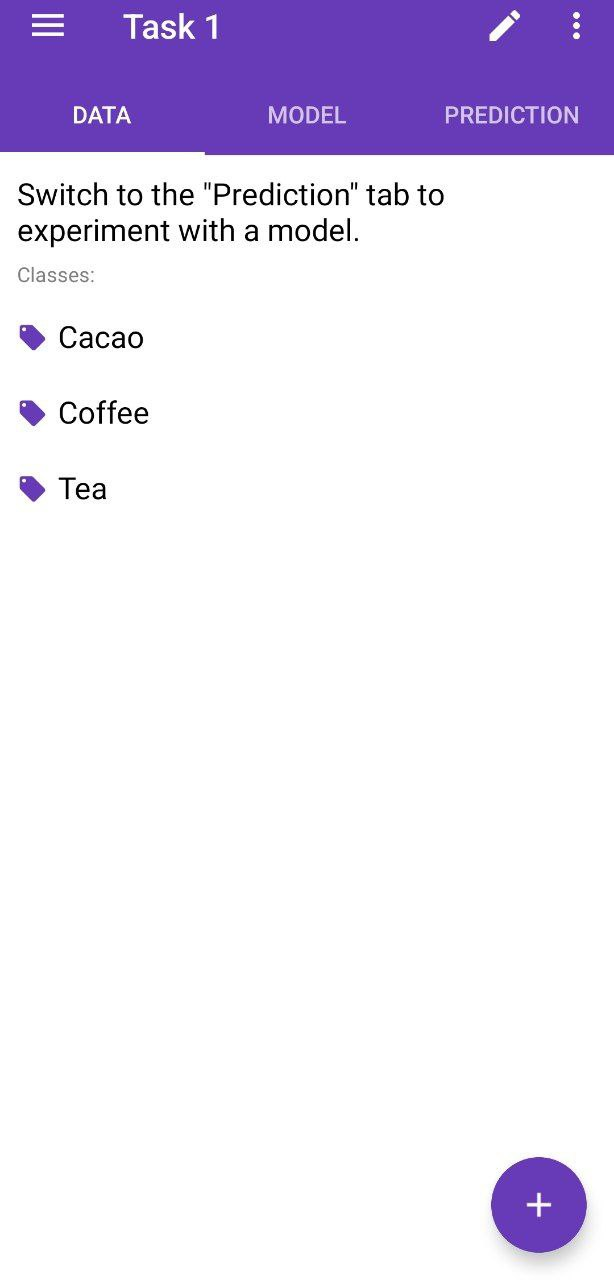


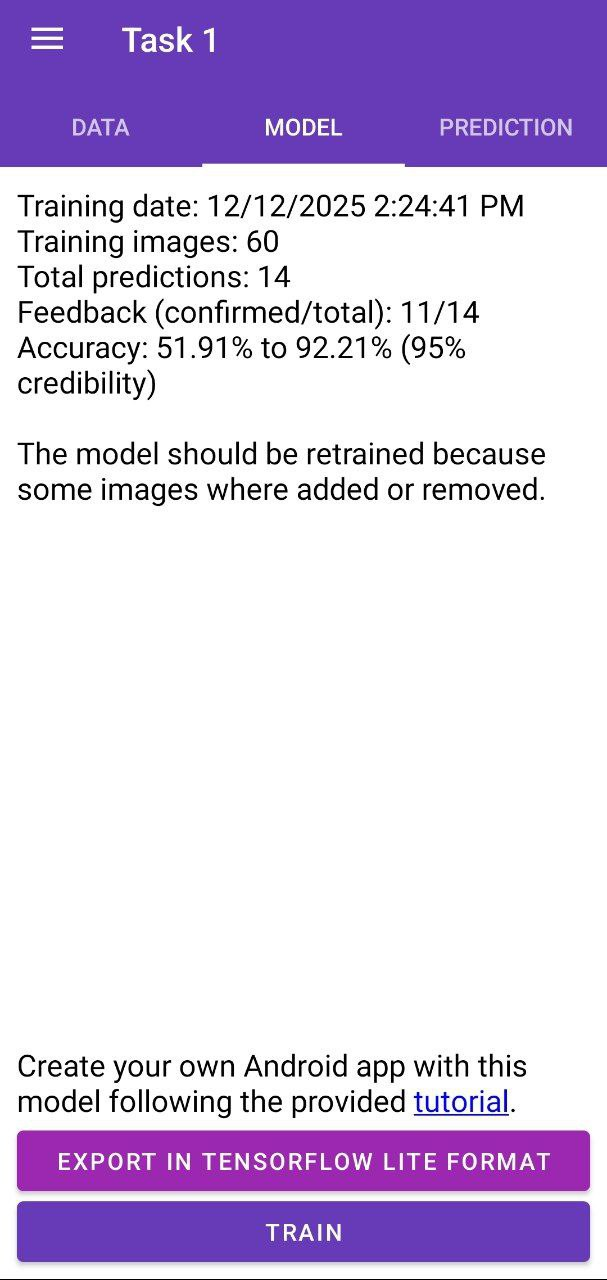